In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import joblib
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage

from src.config import OUTPUTS, IMG_SIZE
from src.mlp import MLP, _cargar_split_pca
from src.cnn import CNN
from src.data import ImageDataset, get_transforms

## 1. MLP

In [2]:
# Cargar PCA y modelo
pca = joblib.load(OUTPUTS / "pca_mlp.joblib")

model = MLP(input_dim=pca.n_components_)
model.load_state_dict(torch.load(OUTPUTS / "mlp_best.pt", map_location="cpu"))
model.eval()

print(f"Componentes PCA: {pca.n_components_}")
print("Modelo cargado.")

Componentes PCA: 352
Modelo cargado.


In [3]:
# Cargar split de test y obtener predicciones
X_test, y_test = _cargar_split_pca("test", pca)

with torch.no_grad():
    logits = model(X_test)
    y_pred = (logits.sigmoid() >= 0.5).int().squeeze().numpy()

y_true = y_test.squeeze().int().numpy()

In [4]:
# Métricas
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1:        {f1_score(y_true, y_pred):.4f}")

Accuracy:  0.7105
Precision: 0.6832
Recall:    0.7857
F1:        0.7309


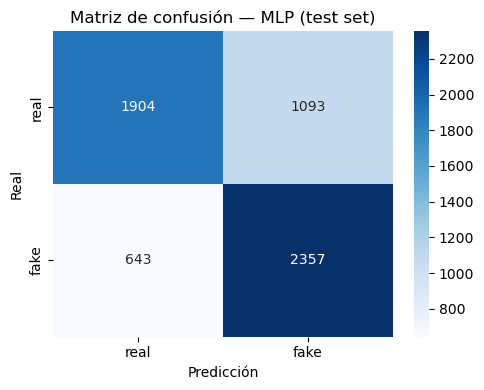

In [5]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["real", "fake"],
            yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — MLP (test set)")
plt.tight_layout()
plt.show()

### Predicción con imagen propia

In [ ]:
# Cambiá esta ruta por la de tu imagen
ruta = Path("mi_imagen.jpg")

with PILImage.open(ruta) as img:
    img_resized = img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))

x = np.array(img_resized, dtype=np.uint8).flatten().reshape(1, -1)
x_pca = pca.transform(x).astype(np.float32)

with torch.no_grad():
    logit = model(torch.from_numpy(x_pca))
    prob  = logit.sigmoid().item()
    pred  = "fake" if prob >= 0.5 else "real"

plt.figure(figsize=(3, 3))
plt.imshow(img_resized)
plt.title(f"Predicción: {pred}  (prob fake: {prob:.2f})", fontsize=10)
plt.axis("off")
plt.show()

## 2. CNN

In [ ]:
cnn_model = CNN()
cnn_model.load_state_dict(torch.load(OUTPUTS / "cnn_best.pt", map_location="cpu"))
cnn_model.eval()
print("CNN cargada.")

In [ ]:
test_loader = DataLoader(ImageDataset("test"), batch_size=128, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = cnn_model(imgs)
        preds  = (logits.sigmoid() >= 0.5).int().squeeze()
        all_preds.append(preds)
        all_labels.append(labels)

y_pred_cnn = torch.cat(all_preds).numpy()
y_true_cnn = torch.cat(all_labels).numpy()

In [ ]:
print(f"Accuracy:  {accuracy_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"Precision: {precision_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"Recall:    {recall_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"F1:        {f1_score(y_true_cnn, y_pred_cnn):.4f}")

In [ ]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["real", "fake"],
            yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — CNN (test set)")
plt.tight_layout()
plt.show()

### Predicción con imagen propia

In [ ]:
# Cambiá esta ruta por la de tu imagen
ruta = Path("mi_imagen.jpg")

with PILImage.open(ruta) as img:
    img_rgb = img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))

transform = get_transforms("val")  # normalización sin augmentation, igual que en test
x = transform(img_rgb).unsqueeze(0)  # (1, 3, 224, 224)

with torch.no_grad():
    logit = cnn_model(x)
    prob  = logit.sigmoid().item()
    pred  = "fake" if prob >= 0.5 else "real"

plt.figure(figsize=(3, 3))
plt.imshow(img_rgb)
plt.title(f"Predicción: {pred}  (prob fake: {prob:.2f})", fontsize=10)
plt.axis("off")
plt.show()